In [ ]:
# Imports necessary libraries for data processing, visualization, and machine learning.
# Includes pandas, numpy for data handling; matplotlib, seaborn for visualization; sklearn, xgboost, imblearn for modeling and preprocessing.
# Constants define cross-validation folds and dataset path, ensuring reproducibility.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Constants ---
N_FOLDS = 5
DATA_PATH = "D:/teesside/Machine learning/Emp_Promotion.csv"

In [ ]:
# Defines utility functions for consistent plotting across analysis.
# Functions standardize chart creation, saving, and display.
def save_plot(title, xlabel, ylabel, filename):
    plt.title(title, fontsize=16, pad=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def plot_histograms_with_stats(df, cols, title, filename, bins=20):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        # Plot histogram for the feature
        sns.histplot(df[col], bins=bins, color='skyblue', alpha=0.7, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        
        # Compute statistics
        mean_val = df[col].mean()
        median_val = df[col].median()
        skewness_val = skew(df[col].dropna())
        
        # Add annotations in the top-right corner
        stats_text = f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}\nSkewness: {skewness_val:.2f}'
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes, 
                     fontsize=9, verticalalignment='top', horizontalalignment='right',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    # Remove empty subplot
    fig.delaxes(axes[-1])
    plt.suptitle(title, y=1.02, fontsize=16)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def plot_heatmap(corr_matrix, title, filename):
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    save_plot(title, '', '', filename)

def plot_class_distribution(y, title, filename):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y, hue=y, palette='Set2', legend=False)
    save_plot(title, 'Class Label', 'Count', filename)

def plot_smote_before_after(y_before, y_after, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    sns.countplot(x=y_before, hue=y_before, palette='Set2', ax=ax1, legend=False)
    ax1.set_title('Before SMOTE')
    ax1.set_xlabel('Class Label')
    ax1.set_ylabel('Count')
    sns.countplot(x=y_after, hue=y_after, palette='Set2', ax=ax2, legend=False)
    ax2.set_title('After SMOTE')
    ax2.set_xlabel('Class Label')
    ax2.set_ylabel('Count')
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def plot_roc_curves(roc_data, title, filename):
    plt.figure(figsize=(8, 6))
    for name, (fpr, tpr, auc) in roc_data.items():
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

In [ ]:
# Loads dataset and selects 8000 rows, ensuring sufficient data for analysis.
# Stratified sampling preserves class distribution of 'is_promoted', addressing imbalance.
# Supports data exploration phase.
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"Error: Dataset file not found at {DATA_PATH}. Please check the file path.")
    exit(1)

if df.shape[0] < 8000:
    print(f"Error: Dataset has {df.shape[0]} rows, fewer than required 8000.")
    exit(1)

df_small, _ = train_test_split(df, train_size=8000, stratify=df['is_promoted'], random_state=42)

# Creates new features to enhance model performance.
# 'training_score_to_rating_ratio' combines performance metrics; 'age_group' categorizes age for interpretability.
df_small['training_score_to_rating_ratio'] = df_small['avg_training_score'] / (df_small['previous_year_rating'] + 1e-5)
df_small['age_group'] = pd.cut(df_small['age'], bins=[0, 30, 45, 100], labels=['Young', 'Mid-Career', 'Senior'])

In [ ]:
# Handles missing values to ensure data quality.
# Uses median for numeric and most frequent for categorical columns, standard preprocessing techniques.
# Prints missing value summary for transparency.
print("\nMissing Values Summary:")
print(df_small.isnull().sum())

numeric_cols = df_small.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df_small.select_dtypes(include=['object', 'category']).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_small[numeric_cols] = num_imputer.fit_transform(df_small[numeric_cols])
df_small[categorical_cols] = cat_imputer.fit_transform(df_small[categorical_cols])


Missing Values Summary:
employee_id                         0
department                          0
region                              0
education                         300
gender                              0
recruitment_channel                 0
no_of_trainings                     0
age                                 0
previous_year_rating              590
length_of_service                   0
awards_won?                         0
avg_training_score                  0
is_promoted                         0
training_score_to_rating_ratio    590
age_group                           0
dtype: int64


In [ ]:
# Removes outliers using IQR method to improve data quality.
# Targets key numeric features to reduce noise, supporting model robustness.
# Prints summary of removed outliers.
def remove_outliers_iqr(data, cols):
    data_clean = data.copy()
    print("\n--- Outlier Removal Summary ---")
    for col in cols:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = data_clean.shape[0]
        data_clean = data_clean[(data_clean[col] >= lower) & (data_clean[col] <= upper)]
        after = data_clean.shape[0]
        print(f"{col}: Removed {before - after} outliers")
    return data_clean

numeric_cols_to_filter = ['age', 'length_of_service', 'previous_year_rating', 'avg_training_score', 'training_score_to_rating_ratio']
df_clean = remove_outliers_iqr(df_small, numeric_cols_to_filter)


--- Outlier Removal Summary ---
age: Removed 220 outliers
length_of_service: Removed 405 outliers
previous_year_rating: Removed 829 outliers
avg_training_score: Removed 0 outliers
training_score_to_rating_ratio: Removed 197 outliers


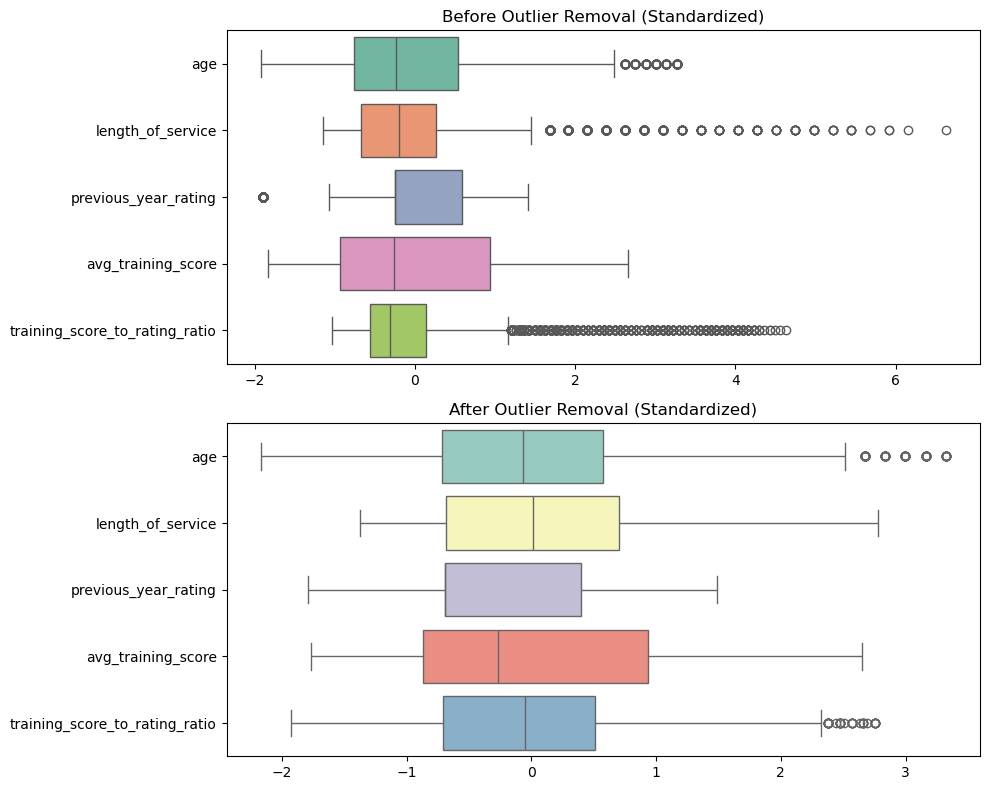

In [ ]:
# Visualizes effect of outlier removal on numeric features.
# Standardized boxplots allow comparison across features.
scaler = StandardScaler()
scaled_before = pd.DataFrame(scaler.fit_transform(df_small[numeric_cols_to_filter]), columns=numeric_cols_to_filter)
scaled_after = pd.DataFrame(scaler.fit_transform(df_clean[numeric_cols_to_filter]), columns=numeric_cols_to_filter)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
sns.boxplot(data=scaled_before, orient="h", palette="Set2", ax=axes[0])
axes[0].set_title("Before Outlier Removal (Standardized)")
sns.boxplot(data=scaled_after, orient="h", palette="Set3", ax=axes[1])
axes[1].set_title("After Outlier Removal (Standardized)")
plt.tight_layout()
plt.savefig("boxplot_comparison_all_numeric_scaled.png")
plt.show()

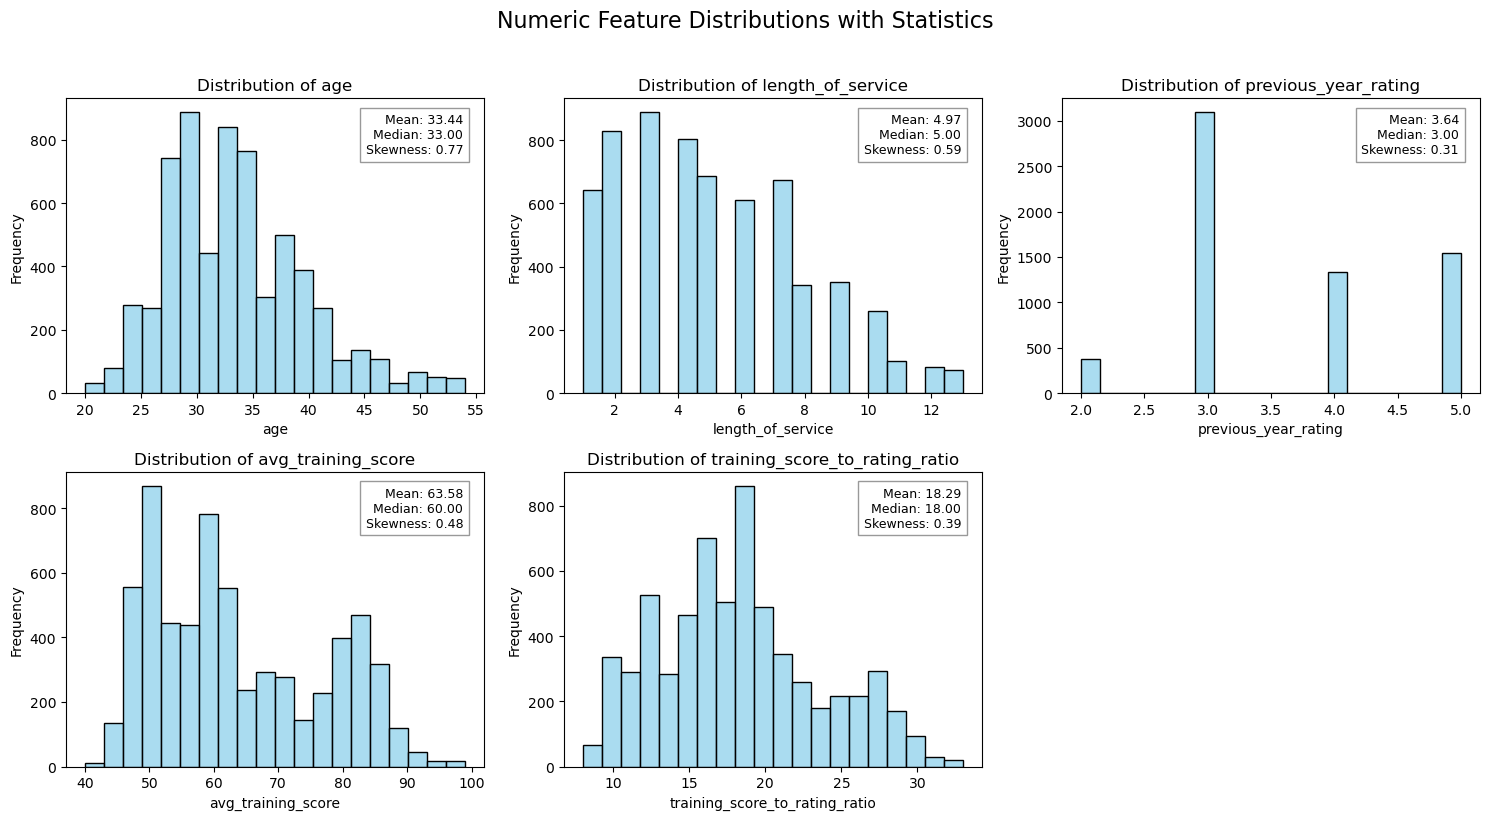

In [ ]:
# Visualizes distribution of numeric features in a 2x3 grid of histograms with statistical annotations.
plot_histograms_with_stats(df_clean, numeric_cols_to_filter, 'Numeric Feature Distributions with Statistics', 'numeric_histograms_with_stats.png')

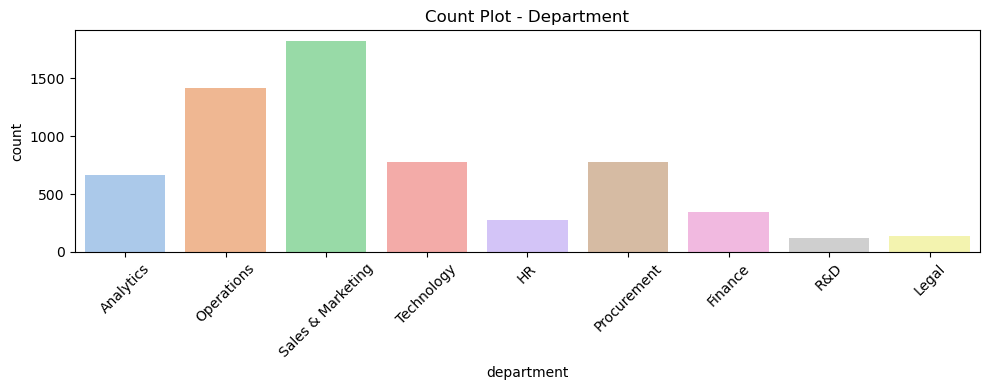

In [ ]:
# Visualizes categorical feature for department.
if 'department' in df_clean.columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df_clean, x='department', hue='department', palette='pastel', legend=False)
    plt.title("Count Plot - Department")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('countplot_department.png')
    plt.show()

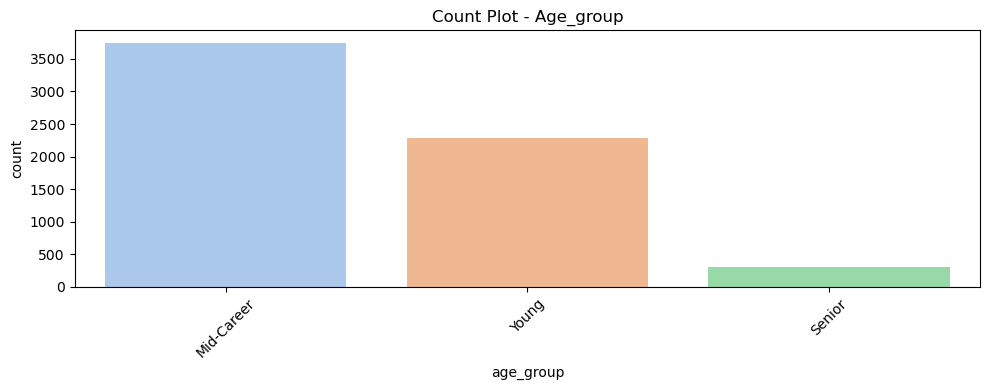

In [ ]:
# Visualizes categorical feature for age_group.
if 'age_group' in df_clean.columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df_clean, x='age_group', hue='age_group', palette='pastel', legend=False)
    plt.title("Count Plot - Age_group")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('countplot_age_group.png')
    plt.show()

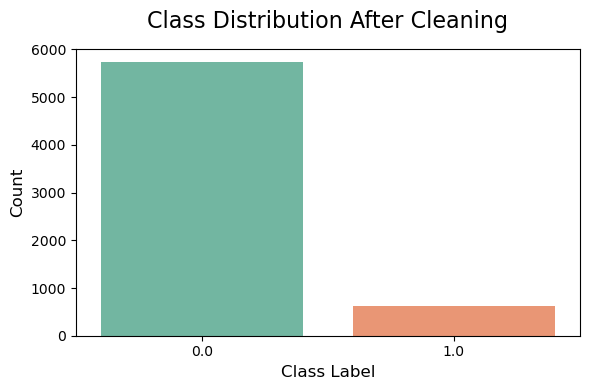

In [ ]:
# Visualizes target variable distribution to assess class imbalance.
plot_class_distribution(df_clean['is_promoted'], 'Class Distribution After Cleaning', 'class_dist_after.png')

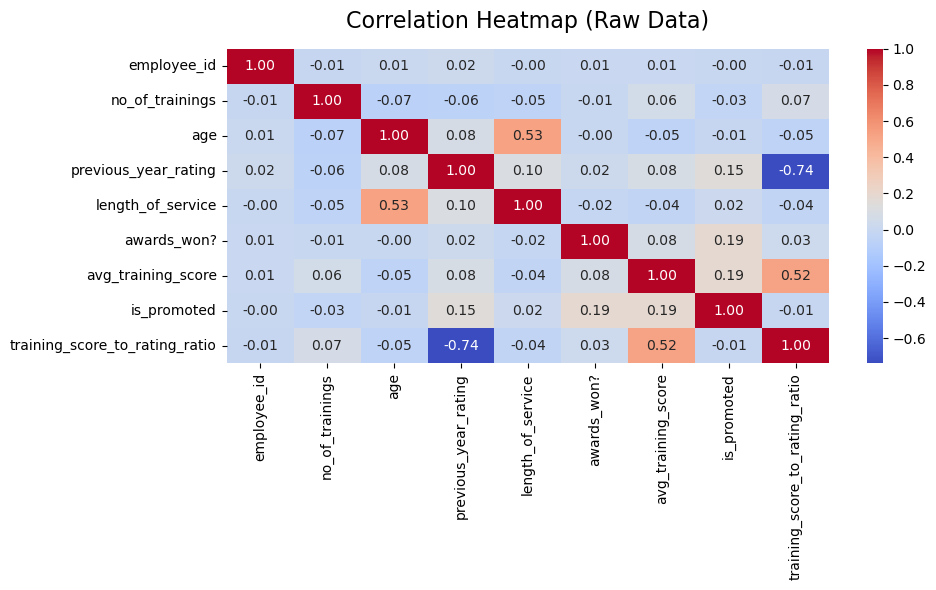

In [ ]:
# Displays correlations to identify feature relationships and multicollinearity.
plot_heatmap(df_clean.corr(numeric_only=True), 'Correlation Heatmap (Raw Data)', 'heatmap_raw.png')

In [ ]:
# Preprocesses data and applies SMOTE to address class imbalance.
# Uses ColumnTransformer for numeric and categorical preprocessing.
# Splits data and prepares for modeling.
X = df_clean.drop(columns=["employee_id", "is_promoted"])
y = df_clean["is_promoted"]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE manually for visualization and PCA analysis only.
# Note: X_resampled and y_resampled are used solely for exploratory analysis (PCA, class distribution plots).
# Model training uses ImbPipeline, which applies SMOTE internally to training data during fit to prevent data leakage.
X_train_processed = preprocessor.fit_transform(X_train)
X_resampled, y_resampled = SMOTE(sampling_strategy=0.5, random_state=42).fit_resample(X_train_processed, y_train)

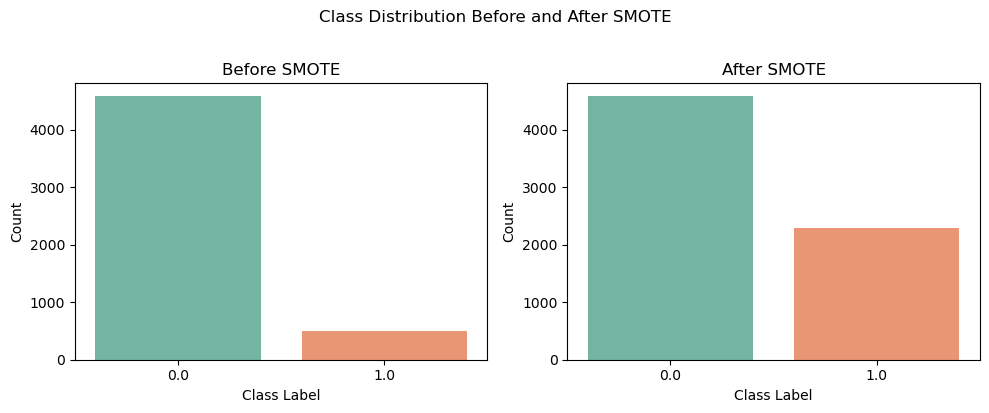

In [ ]:
# Visualizes class distribution before and after SMOTE in a single figure to justify imbalance correction.
plot_smote_before_after(y_train, y_resampled, 'Class Distribution Before and After SMOTE', 'smote_before_after.png')

In [ ]:
# Applies PCA to reduce dimensionality for visualization.
# Prepares data for variance plot and 2D projection.
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_resampled)

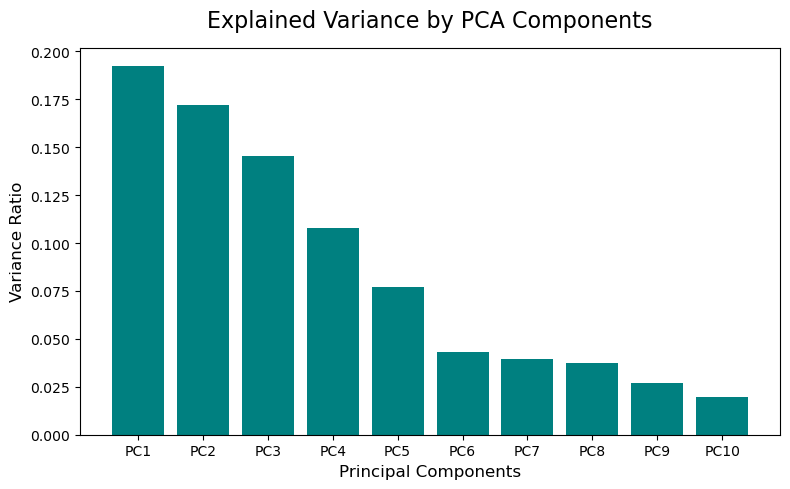

In [ ]:
# Visualizes explained variance by PCA components to justify component selection.
plt.figure(figsize=(8, 5))
plt.bar(range(1, 11), pca.explained_variance_ratio_, tick_label=[f'PC{i}' for i in range(1, 11)], color='teal')
save_plot('Explained Variance by PCA Components', 'Principal Components', 'Variance Ratio', 'pca_variance.png')

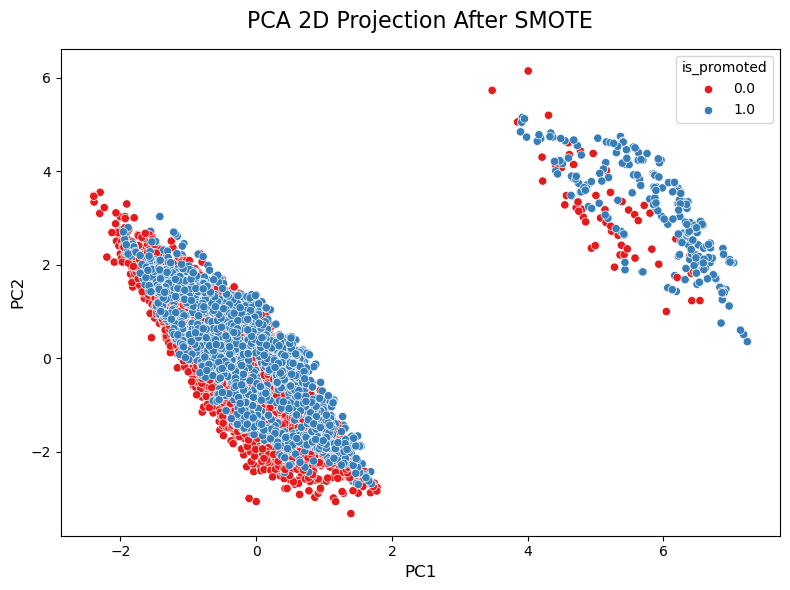

In [ ]:
# Visualizes 2D PCA projection to show class separability.
pca_2d = PCA(n_components=2)
components = pca_2d.fit_transform(X_resampled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=y_resampled, palette='Set1')
save_plot('PCA 2D Projection After SMOTE', 'PC1', 'PC2', 'pca_2d.png')

In [ ]:
# Defines four ML models (Logistic Regression, Random Forest, XGBoost, SVM) and their hyperparameter grids.
# Models chosen for diversity (linear, tree-based, gradient boosting, kernel-based) to suit promotion prediction.
model_defs = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(objective='binary:logistic'),
    "SVM": SVC(probability=True, class_weight='balanced')
}

param_grids = {
    "Logistic Regression": {'clf__C': [0.1, 1, 10]},
    "Random Forest": {'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 10]},
    "XGBoost": {
        'clf__n_estimators': [100, 200, 300],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5, 7],
        'clf__min_child_weight': [1, 3],
        'clf__subsample': [0.8, 1.0]
    },
    "SVM": {'clf__C': [0.1, 1], 'clf__kernel': ['rbf']}
}

# Initializes dictionaries to store ROC curves, model metrics, cross-validation scores, and best models.
# Ensures variables are defined before model evaluation, preventing NameError and supporting robust analysis.
roc_pre_tuning = {}
roc_post_tuning = {}
model_metrics = []
cv_scores = {}
best_models = {}

In [ ]:
# Trains and evaluates Logistic Regression with hyperparameter tuning.
# Stores results for visualization.
print("\n=== Logistic Regression ===")
# Pipeline includes preprocessing, SMOTE for class imbalance, and classifier.
# SMOTE is applied to training data only during fit to prevent data leakage.
pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('clf', model_defs["Logistic Regression"])
])
pipe.fit(X_train, y_train)
y_proba_pre = pipe.predict_proba(X_test)[:, 1]
fpr_pre, tpr_pre, _ = roc_curve(y_test, y_proba_pre)
auc_pre = roc_auc_score(y_test, y_proba_pre)
roc_pre_tuning["Logistic Regression"] = (fpr_pre, tpr_pre, auc_pre)

grid = GridSearchCV(pipe, param_grids["Logistic Regression"], cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
best_models["Logistic Regression"] = grid.best_estimator_
y_pred_lr = best_models["Logistic Regression"].predict(X_test)
y_proba_lr = best_models["Logistic Regression"].predict_proba(X_test)[:, 1]
fpr_post, tpr_post, _ = roc_curve(y_test, y_proba_lr)
auc_post = roc_auc_score(y_test, y_proba_lr)
roc_post_tuning["Logistic Regression"] = (fpr_post, tpr_post, auc_post)

acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
model_metrics.append(["Logistic Regression", acc, prec, rec, f1])

print(f"\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

scores = cross_val_score(pipe, X, y, cv=N_FOLDS, scoring='f1', n_jobs=-1)
cv_scores["Logistic Regression"] = scores


=== Logistic Regression ===

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.95      0.76      0.84      1146
         1.0       0.22      0.65      0.33       124

    accuracy                           0.75      1270
   macro avg       0.59      0.70      0.59      1270
weighted avg       0.88      0.75      0.79      1270



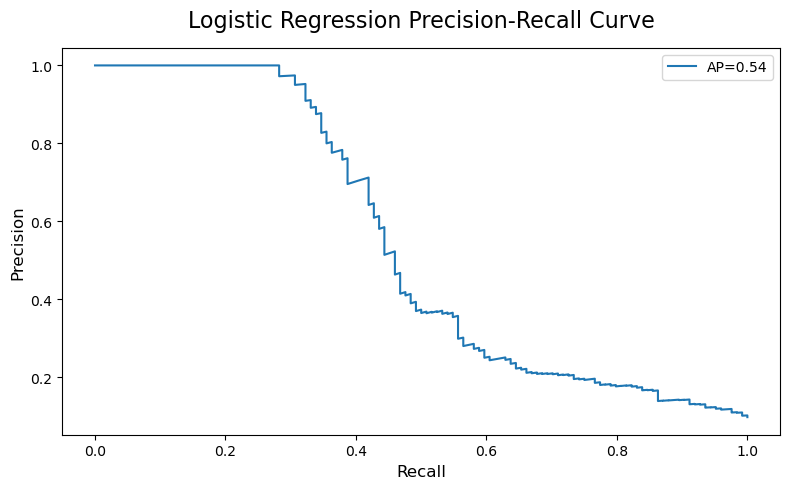

In [ ]:
# Visualizes precision-recall curve for Logistic Regression.
precision, recall, _ = precision_recall_curve(y_test, y_proba_lr)
ap = average_precision_score(y_test, y_proba_lr)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'AP={ap:.2f}')
plt.legend()
save_plot("Logistic Regression Precision-Recall Curve", "Recall", "Precision", "pr_logistic_regression.png")

<Figure size 600x500 with 0 Axes>

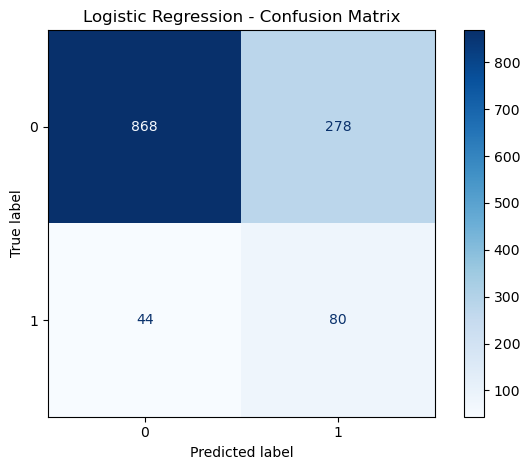

In [ ]:
# Visualizes confusion matrix for Logistic Regression.
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_logistic_regression.png")
plt.show()

In [ ]:
# Trains and evaluates Random Forest.
# Stores results for visualization
print("\n=== Random Forest ===")
# Pipeline includes preprocessing, SMOTE for class imbalance, and classifier.
# SMOTE is applied to training data only during fit to prevent data leakage.
pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('clf', model_defs["Random Forest"])
])
pipe.fit(X_train, y_train)
y_proba_pre = pipe.predict_proba(X_test)[:, 1]
fpr_pre, tpr_pre, _ = roc_curve(y_test, y_proba_pre)
auc_pre = roc_auc_score(y_test, y_proba_pre)
roc_pre_tuning["Random Forest"] = (fpr_pre, tpr_pre, auc_pre)

grid = GridSearchCV(pipe, param_grids["Random Forest"], cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
best_models["Random Forest"] = grid.best_estimator_
y_pred_rf = best_models["Random Forest"].predict(X_test)
y_proba_rf = best_models["Random Forest"].predict_proba(X_test)[:, 1]
fpr_post, tpr_post, _ = roc_curve(y_test, y_proba_rf)
auc_post = roc_auc_score(y_test, y_proba_rf)
roc_post_tuning["Random Forest"] = (fpr_post, tpr_post, auc_post)

acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
model_metrics.append(["Random Forest", acc, prec, rec, f1])

print(f"\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

scores = cross_val_score(pipe, X, y, cv=N_FOLDS, scoring='f1', n_jobs=-1)
cv_scores["Random Forest"] = scores


=== Random Forest ===

Classification Report for Random Forest:
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95      1146
         1.0       0.59      0.16      0.25       124

    accuracy                           0.91      1270
   macro avg       0.75      0.57      0.60      1270
weighted avg       0.88      0.91      0.88      1270



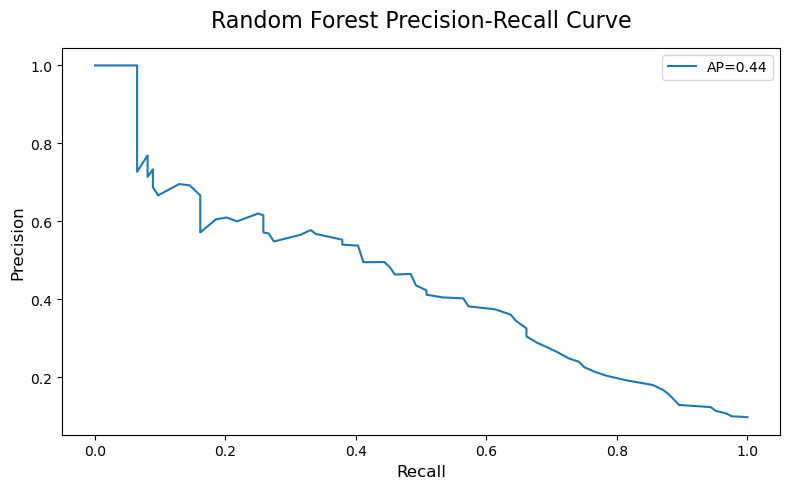

In [ ]:
# Visualizes precision-recall curve for Random Forest.
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
ap = average_precision_score(y_test, y_proba_rf)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'AP={ap:.2f}')
plt.legend()
save_plot("Random Forest Precision-Recall Curve", "Recall", "Precision", "pr_random_forest.png")

<Figure size 600x500 with 0 Axes>

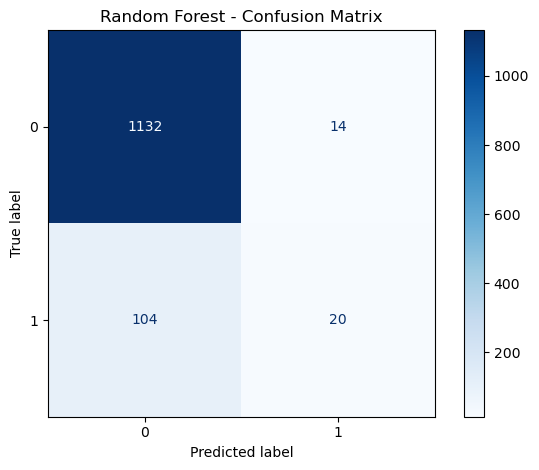

In [ ]:
# Visualizes confusion matrix for Random Forest.
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_random_forest.png")
plt.show()

In [ ]:
# Trains and evaluates XGBoost.
print("\n=== XGBoost ===")
# Pipeline includes preprocessing, SMOTE for class imbalance, and classifier.
# SMOTE is applied to training data only during fit to prevent data leakage.
pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('clf', model_defs["XGBoost"])
])
pipe.fit(X_train, y_train)
y_proba_pre = pipe.predict_proba(X_test)[:, 1]
fpr_pre, tpr_pre, _ = roc_curve(y_test, y_proba_pre)
auc_pre = roc_auc_score(y_test, y_proba_pre)
roc_pre_tuning["XGBoost"] = (fpr_pre, tpr_pre, auc_pre)

grid = GridSearchCV(pipe, param_grids["XGBoost"], cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
best_models["XGBoost"] = grid.best_estimator_
y_pred_xgb = best_models["XGBoost"].predict(X_test)
y_proba_xgb = best_models["XGBoost"].predict_proba(X_test)[:, 1]
fpr_post, tpr_post, _ = roc_curve(y_test, y_proba_xgb)
auc_post = roc_auc_score(y_test, y_proba_xgb)
roc_post_tuning["XGBoost"] = (fpr_post, tpr_post, auc_post)

acc = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
model_metrics.append(["XGBoost", acc, prec, rec, f1])

print(f"\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

scores = cross_val_score(pipe, X, y, cv=N_FOLDS, scoring='f1', n_jobs=-1)
cv_scores["XGBoost"] = scores


=== XGBoost ===

Classification Report for XGBoost:
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96      1146
         1.0       0.88      0.30      0.45       124

    accuracy                           0.93      1270
   macro avg       0.91      0.65      0.70      1270
weighted avg       0.92      0.93      0.91      1270



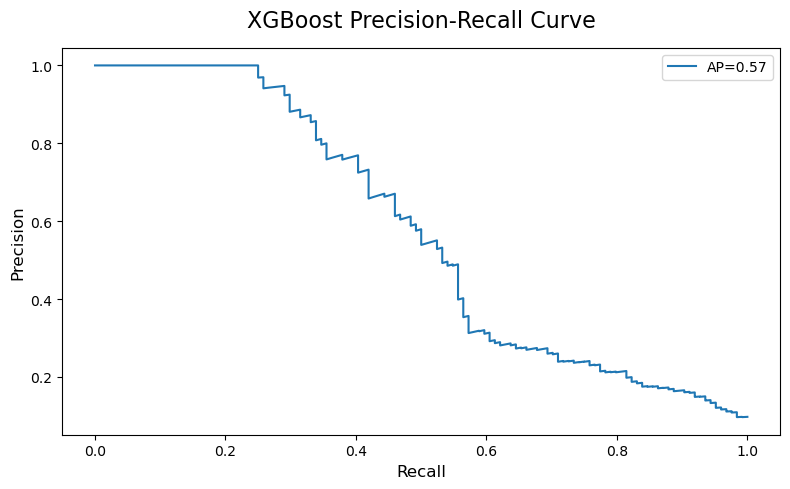

In [ ]:
# Visualizes precision-recall curve for XGBoost.
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
ap = average_precision_score(y_test, y_proba_xgb)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'AP={ap:.2f}')
plt.legend()
save_plot("XGBoost Precision-Recall Curve", "Recall", "Precision", "pr_xgboost.png")

<Figure size 600x500 with 0 Axes>

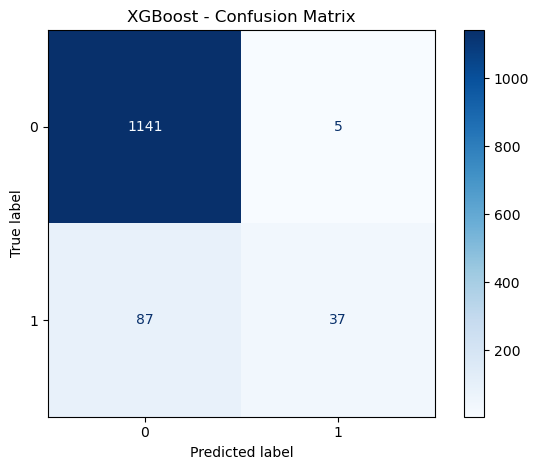

In [ ]:
# Visualizes confusion matrix for XGBoost.
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_xgboost.png")
plt.show()

In [ ]:
# Trains and evaluates SVM.
print("\n=== SVM ===")
# Pipeline includes preprocessing, SMOTE for class imbalance, and classifier.
# SMOTE is applied to training data only during fit to prevent data leakage.
pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('clf', model_defs["SVM"])
])
pipe.fit(X_train, y_train)
y_proba_pre = pipe.predict_proba(X_test)[:, 1]
fpr_pre, tpr_pre, _ = roc_curve(y_test, y_proba_pre)
auc_pre = roc_auc_score(y_test, y_proba_pre)
roc_pre_tuning["SVM"] = (fpr_pre, tpr_pre, auc_pre)

grid = GridSearchCV(pipe, param_grids["SVM"], cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
best_models["SVM"] = grid.best_estimator_
y_pred_svm = best_models["SVM"].predict(X_test)
y_proba_svm = best_models["SVM"].predict_proba(X_test)[:, 1]
fpr_post, tpr_post, _ = roc_curve(y_test, y_proba_svm)
auc_post = roc_auc_score(y_test, y_proba_svm)
roc_post_tuning["SVM"] = (fpr_post, tpr_post, auc_post)

acc = accuracy_score(y_test, y_pred_svm)
prec = precision_score(y_test, y_pred_svm)
rec = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)
model_metrics.append(["SVM", acc, prec, rec, f1])

print(f"\nClassification Report for SVM:")
print(classification_report(y_test, y_pred_svm))

scores = cross_val_score(pipe, X, y, cv=N_FOLDS, scoring='f1', n_jobs=-1)
cv_scores["SVM"] = scores


=== SVM ===

Classification Report for SVM:
              precision    recall  f1-score   support

         0.0       0.95      0.85      0.90      1146
         1.0       0.29      0.56      0.38       124

    accuracy                           0.82      1270
   macro avg       0.62      0.70      0.64      1270
weighted avg       0.88      0.82      0.85      1270



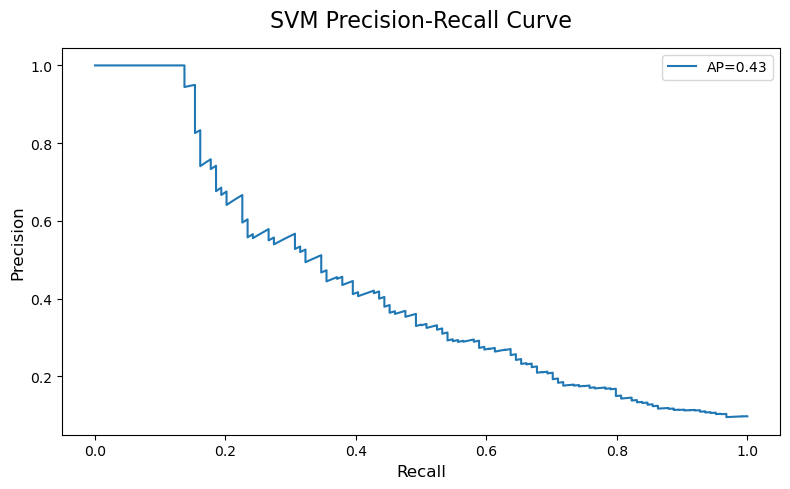

In [ ]:
# Visualizes precision-recall curve for SVM.
precision, recall, _ = precision_recall_curve(y_test, y_proba_svm)
ap = average_precision_score(y_test, y_proba_svm)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'AP={ap:.2f}')
plt.legend()
save_plot("SVM Precision-Recall Curve", "Recall", "Precision", "pr_svm.png")

<Figure size 600x500 with 0 Axes>

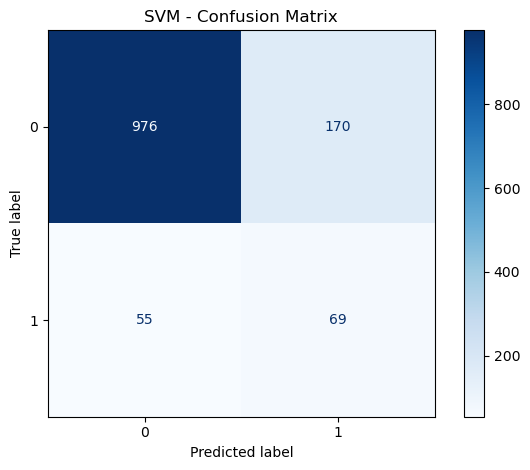

In [ ]:
# Visualizes confusion matrix for SVM.
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("SVM - Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png")
plt.show()

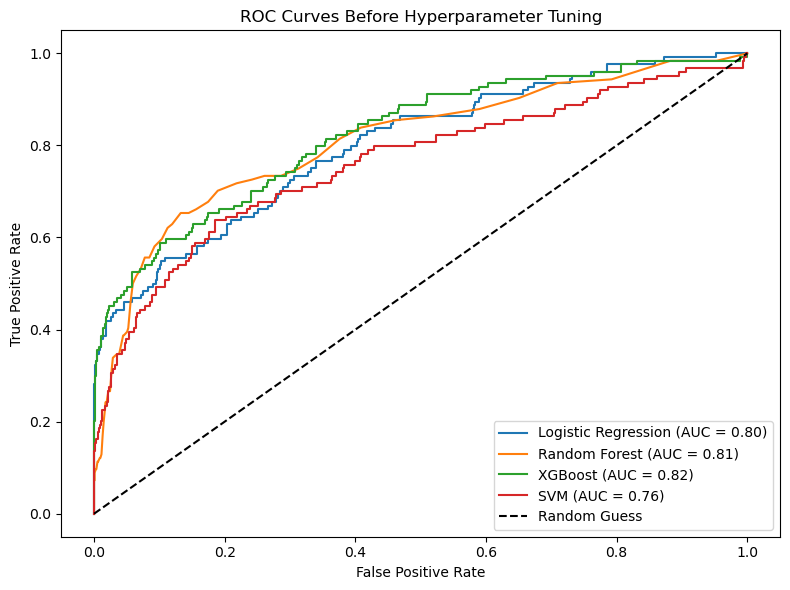

In [ ]:
# Compares ROC curves before hyperparameter tuning for all models.
plot_roc_curves(roc_pre_tuning, "ROC Curves Before Hyperparameter Tuning", "roc_pre_tuning.png")

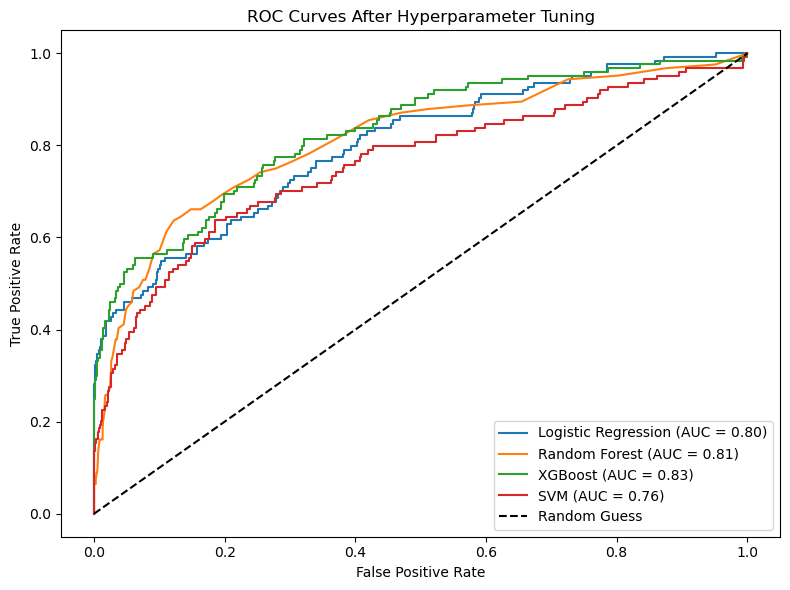

In [ ]:
# Compares ROC curves after hyperparameter tuning for all models.
plot_roc_curves(roc_post_tuning, "ROC Curves After Hyperparameter Tuning", "roc_post_tuning.png")

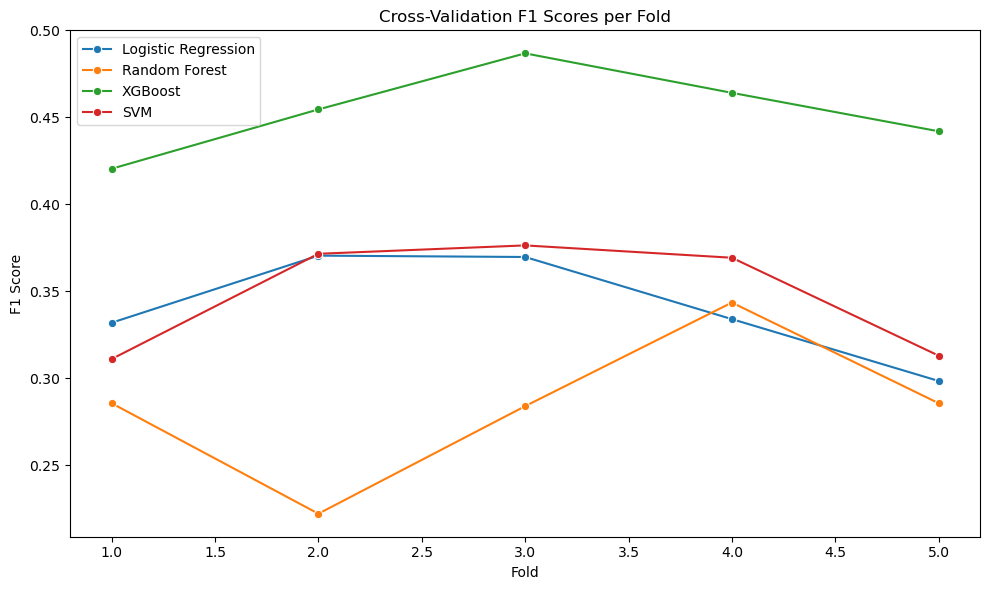

In [ ]:
# Visualizes F1 scores across CV folds to assess model stability.
plt.figure(figsize=(10, 6))
for name_cv, scores in cv_scores.items():
    sns.lineplot(x=range(1, N_FOLDS + 1), y=scores, marker='o', label=name_cv)
plt.title("Cross-Validation F1 Scores per Fold")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig("cv_f1_scores.png")
plt.show()

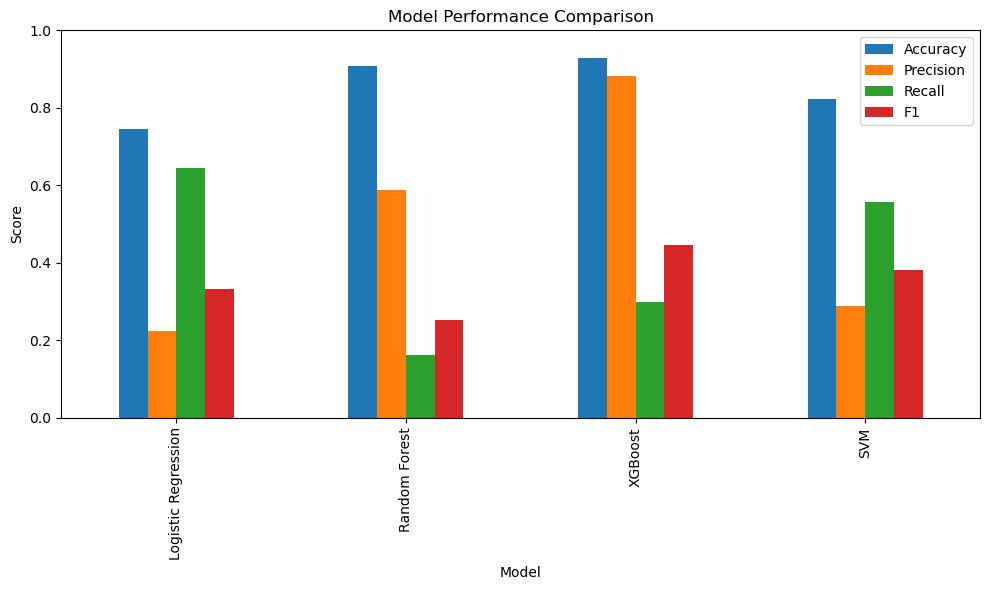

In [ ]:
# Compares model metrics (accuracy, precision, recall, F1) to justify model selection.
if model_metrics:
    metrics_df = pd.DataFrame(model_metrics, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
    metrics_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
    plt.title('Model Performance Comparison')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig('model_comparison_scores.png')
    plt.show()

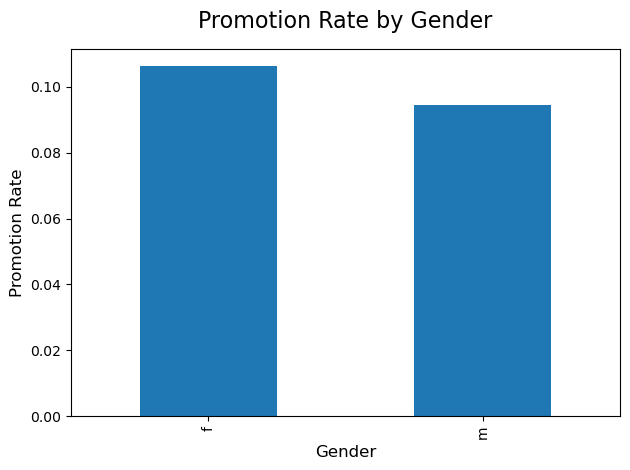

In [ ]:
# Analyzes promotion rates by gender to assess fairness.
# Bar plot visualizes potential gender biases.
if 'gender' in df_clean.columns and df_clean['gender'].notna().any():
    fairness_stats = df_clean.groupby('gender')['is_promoted'].mean()
    fairness_stats.plot(kind='bar')
    save_plot('Promotion Rate by Gender', 'Gender', 'Promotion Rate', 'fairness_gender.png')

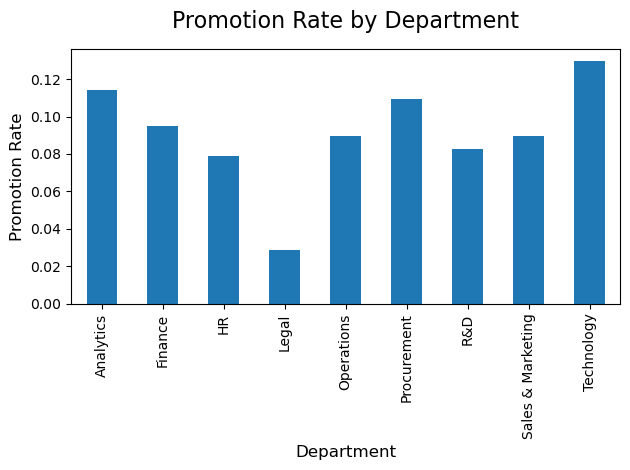

In [ ]:
# Examines promotion rates by department to identify organizational biases.
if 'department' in df_clean.columns and df_clean['department'].notna().any():
    fairness_stats = df_clean.groupby('department')['is_promoted'].mean()
    fairness_stats.plot(kind='bar')
    save_plot('Promotion Rate by Department', 'Department', 'Promotion Rate', 'fairness_department.png')

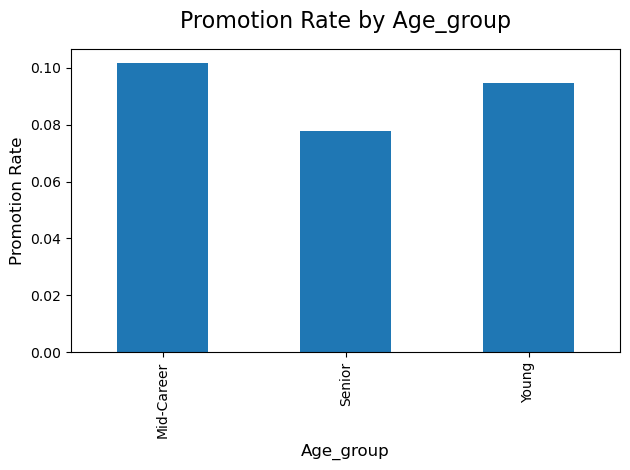

In [ ]:
# Analyzes promotion rates by age group to assess age-related biases.
if 'age_group' in df_clean.columns and df_clean['age_group'].notna().any():
    fairness_stats = df_clean.groupby('age_group')['is_promoted'].mean()
    fairness_stats.plot(kind='bar')
    save_plot('Promotion Rate by Age_group', 'Age_group', 'Promotion Rate', 'fairness_age_group.png')